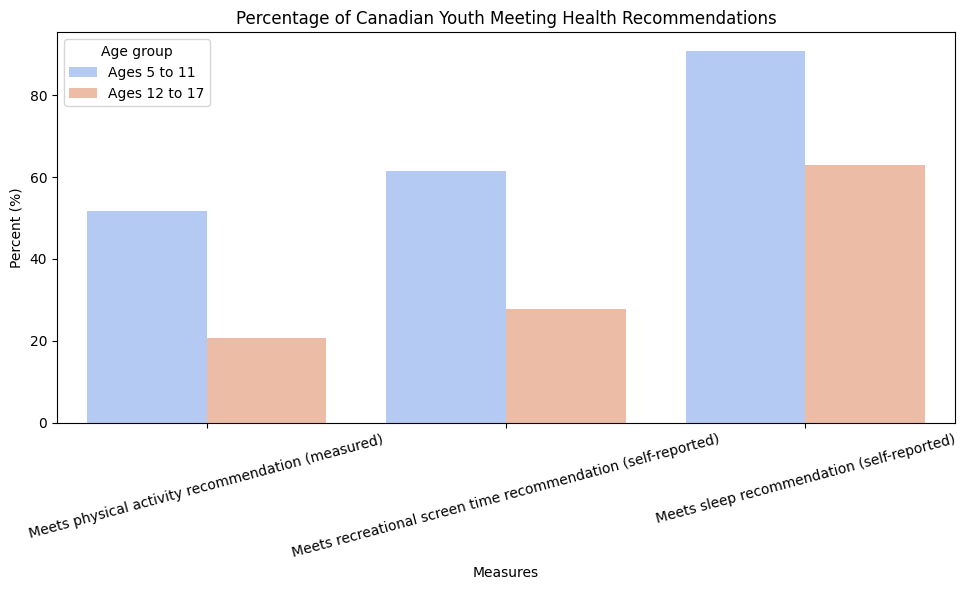

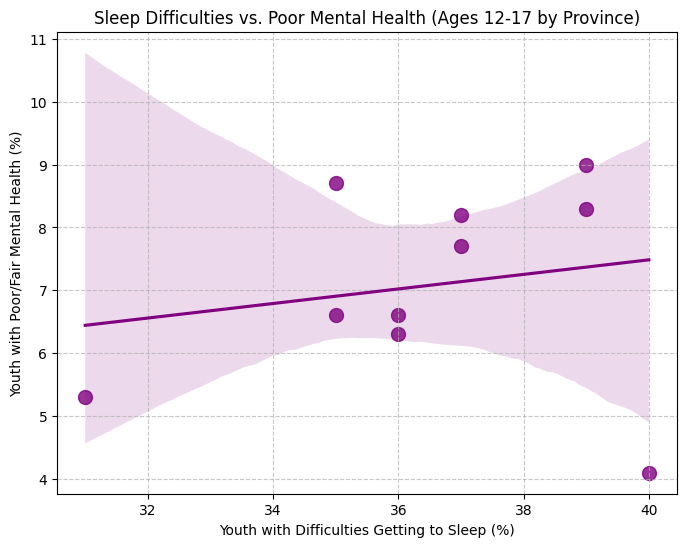

Correlation Analysis: r = 0.189, p-value = 0.6001

Paired T-test (Puberty Sleep): T-stat = 17.459, p-value = 0.0000
Average Sleep Diff (Ages 5-11): 20.1%
Average Sleep Diff (Ages 12-17): 36.5%

--- Regression Model Summary ---
                            OLS Regression Results                            
Dep. Variable:     Poor_Mental_Health   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                 -0.085
Method:                 Least Squares   F-statistic:                    0.2980
Date:                Wed, 15 Apr 2026   Prob (F-statistic):              0.600
Time:                        10:39:42   Log-Likelihood:                -18.074
No. Observations:                  10   AIC:                             40.15
Df Residuals:                       8   BIC:                             40.75
Df Model:                           1                                         
Covariance Type:            nonrobust                         

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# 1. Load the Data
df1 = pd.read_csv('13100763.csv')
df2 = pd.read_csv('13100969.csv')


# Objective 1: Describe Sleep Distributions
# Filter for Canadian youth meeting health guidelines
df2_guidelines = df2[
    (df2['Sex'] == 'Both sexes') & 
    (df2['Characteristics'] == 'Percent') &
    (df2['Age group'].isin(['Ages 5 to 11', 'Ages 12 to 17'])) &
    (df2['Measures'].isin([
        'Meets physical activity recommendation (measured)',
        'Meets recreational screen time recommendation (self-reported)',
        'Meets sleep recommendation (self-reported)'
    ]))
]

plt.figure(figsize=(10, 6))
sns.barplot(data=df2_guidelines, x='Measures', y='VALUE', hue='Age group', palette='coolwarm')
plt.title('Percentage of Canadian Youth Meeting Health Recommendations')
plt.ylabel('Percent (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# Objective 2: Correlation Analysis
# Isolate the 10 provinces to compare Sleep Difficulties vs. Mental Health in Teens
provinces = ['Newfoundland and Labrador', 'Prince Edward Island', 'Nova Scotia', 
             'New Brunswick', 'Quebec', 'Ontario', 'Manitoba', 'Saskatchewan', 'Alberta', 'British Columbia']

df1_teens = df1[
    (df1['Age group'] == '12 to 17 years') & 
    (df1['Sex'] == 'Both sexes') & 
    (df1['Characteristics'] == 'Percent') &
    (df1['GEO'].isin(provinces))
]

# Extract the two variables we want to correlate
sleep_diff = df1_teens[df1_teens['Indicators'].str.contains('Difficulties in getting to sleep', na=False)][['GEO', 'VALUE']].rename(columns={'VALUE': 'Sleep_Diff'})
mental_health = df1_teens[df1_teens['Indicators'] == 'Perceived mental health, fair or poor'][['GEO', 'VALUE']].rename(columns={'VALUE': 'Poor_Mental_Health'})

corr_df = pd.merge(sleep_diff, mental_health, on='GEO').dropna()

# Plot the correlation
plt.figure(figsize=(8, 6))
sns.regplot(data=corr_df, x='Sleep_Diff', y='Poor_Mental_Health', scatter_kws={'s':100}, color='purple')
plt.title('Sleep Difficulties vs. Poor Mental Health (Ages 12-17 by Province)')
plt.xlabel('Youth with Difficulties Getting to Sleep (%)')
plt.ylabel('Youth with Poor/Fair Mental Health (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Calculate Pearson Correlation
pearson_corr, p_value_corr = stats.pearsonr(corr_df['Sleep_Diff'], corr_df['Poor_Mental_Health'])
print(f"Correlation Analysis: r = {pearson_corr:.3f}, p-value = {p_value_corr:.4f}")


# Objective 3: Hypothesis Testing
# Hypothesis: Sleep difficulties significantly worsen as children enter puberty (12-17) compared to pre-puberty (5-11).
df1_sleep = df1[
    (df1['Indicators'].str.contains('Difficulties in getting to sleep', na=False)) &
    (df1['Sex'] == 'Both sexes') &
    (df1['Characteristics'] == 'Percent') &
    (df1['GEO'].isin(provinces))
]

sleep_kids = df1_sleep[df1_sleep['Age group'] == '5 to 11 years'][['GEO', 'VALUE']].rename(columns={'VALUE': 'Kids_5_11'})
sleep_teens = df1_sleep[df1_sleep['Age group'] == '12 to 17 years'][['GEO', 'VALUE']].rename(columns={'VALUE': 'Teens_12_17'})
ttest_df = pd.merge(sleep_kids, sleep_teens, on='GEO').dropna()

# Paired T-Test
t_stat, p_val_ttest = stats.ttest_rel(ttest_df['Teens_12_17'], ttest_df['Kids_5_11'])
print(f"\nPaired T-test (Puberty Sleep): T-stat = {t_stat:.3f}, p-value = {p_val_ttest:.4f}")
print(f"Average Sleep Diff (Ages 5-11): {ttest_df['Kids_5_11'].mean():.1f}%")
print(f"Average Sleep Diff (Ages 12-17): {ttest_df['Teens_12_17'].mean():.1f}%")


# Objective 4: Regression Modelling
# Predict Poor Mental Health based on Sleep Difficulties
X = corr_df['Sleep_Diff']
X = sm.add_constant(X)
y = corr_df['Poor_Mental_Health']

model = sm.OLS(y, X).fit()
print("\n--- Regression Model Summary ---")
print(model.summary())